# Demand Forecasting Model

Forecasts daily citywide yellow-taxi trip volume. Yellow is used alone since it's 98.6% of combined volume (see the market-structure analysis) - green's much smaller, noisier counts would add little signal. Grain is daily rather than hourly to keep this a focused first forecasting pass; the hour-of-day/day-of-week demand shape from the main analysis is a natural next feature set to extend this to.

In [1]:
%matplotlib inline
import os, warnings
warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import sqlalchemy as sa
from dotenv import load_dotenv

load_dotenv("../../.env")
url = (
    f"postgresql+psycopg2://{os.environ['WAREHOUSE_DB_USER']}:{os.environ['WAREHOUSE_DB_PASSWORD']}"
    f"@{os.environ['WAREHOUSE_DB_HOST']}:{os.environ['WAREHOUSE_DB_PORT']}/{os.environ['WAREHOUSE_DB_NAME']}"
)
engine = sa.create_engine(url)

BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
INK, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY, "text.color": INK, "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})


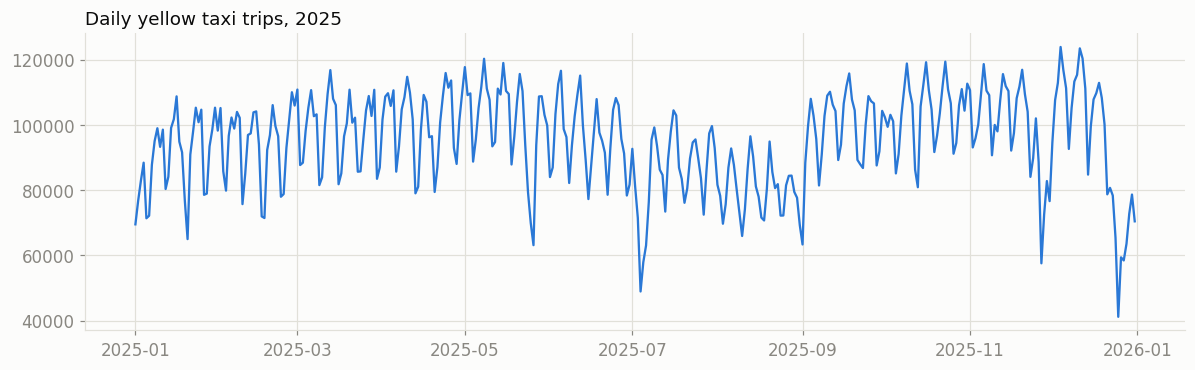

In [2]:
daily = pd.read_sql("""
    select pickup_date, sum(trip_count) as trips
    from dbt_dev_marts.agg_daily_zone
    where taxi_type = \'yellow\' and pickup_date between \'2025-01-01\' and \'2025-12-31\'
    group by 1 order by 1
""", engine)
daily["pickup_date"] = pd.to_datetime(daily.pickup_date)
daily = daily.set_index("pickup_date").asfreq("D")
assert daily.trips.isna().sum() == 0, "gap in the daily series"

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(daily.index, daily.trips, color=BLUE, linewidth=1.5)
ax.set_title("Daily yellow taxi trips, 2025", loc="left", fontsize=12, color=INK)
plt.tight_layout()
plt.show()


## Feature engineering

Lag and rolling-mean features carry most of a demand series' predictable structure: yesterday's volume, the same day last week (captures weekly seasonality directly), and short/medium rolling averages (captures the smoother month-to-month drift visible in the plot above).

In [3]:
daily["day_of_week"] = daily.index.dayofweek
daily["month"] = daily.index.month
daily["lag_1"] = daily.trips.shift(1)
daily["lag_7"] = daily.trips.shift(7)
daily["roll_mean_7"] = daily.trips.shift(1).rolling(7).mean()
daily["roll_mean_28"] = daily.trips.shift(1).rolling(28).mean()

model_df = daily.dropna()
train = model_df[model_df.index < "2025-11-01"]
test = model_df[model_df.index >= "2025-11-01"]

FEATURES = ["day_of_week", "month", "lag_1", "lag_7", "roll_mean_7", "roll_mean_28"]
X_train, y_train = train[FEATURES], train.trips
X_test, y_test = test[FEATURES], test.trips
print(f"train: {len(train)} days (through Oct)   test: {len(test)} days (Nov-Dec)")


train: 276 days (through Oct)   test: 61 days (Nov-Dec)


## Baseline vs. model

The baseline here is "predict the same volume as the same day last week" - a strong, realistic baseline for a series this seasonal, and the bar the model actually needs to clear to be useful.

In [4]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import xgboost as xgb

naive_pred = test.lag_7
mae_naive = mean_absolute_error(y_test, naive_pred)
mape_naive = mean_absolute_percentage_error(y_test, naive_pred) * 100
print(f"Naive (same day last week):  MAE={mae_naive:,.0f} trips   MAPE={mape_naive:.2f}%")

model = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred) * 100
print(f"XGBoost:                     MAE={mae:,.0f} trips   MAPE={mape:.2f}%")
print(f"Relative improvement over naive baseline: {(1 - mape/mape_naive)*100:.0f}%")


Naive (same day last week):  MAE=13,248 trips   MAPE=17.41%


XGBoost:                     MAE=8,179 trips   MAPE=10.10%
Relative improvement over naive baseline: 42%


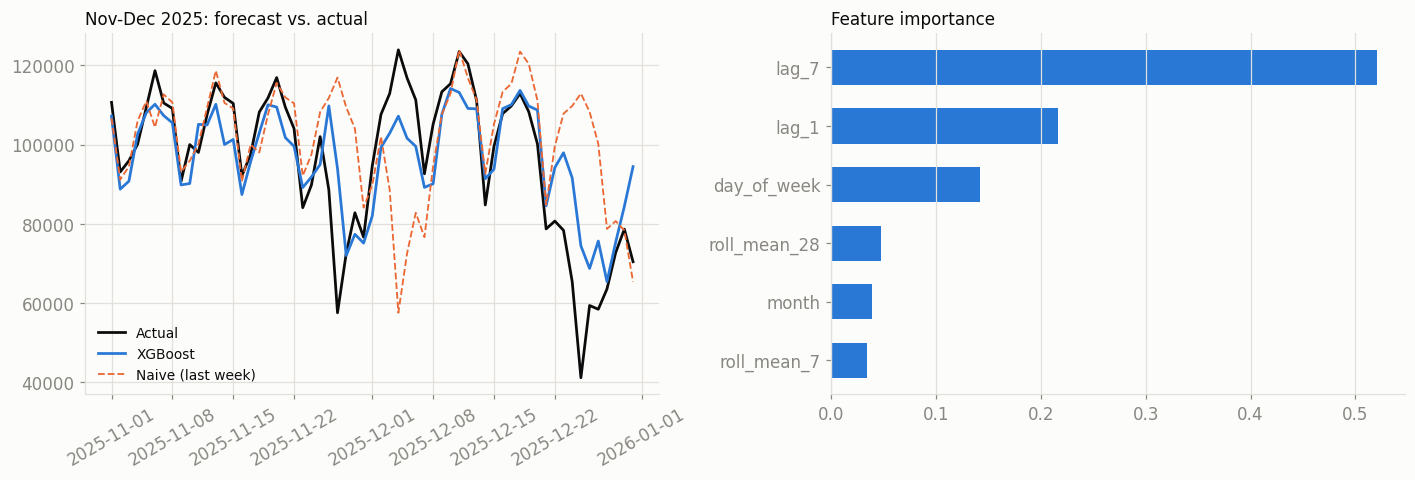

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(test.index, y_test, color=INK, linewidth=1.8, label="Actual")
axes[0].plot(test.index, pred, color=BLUE, linewidth=1.8, label="XGBoost")
axes[0].plot(test.index, naive_pred, color=ORANGE, linewidth=1.2, linestyle="--", label="Naive (last week)")
axes[0].set_title("Nov-Dec 2025: forecast vs. actual", loc="left", fontsize=11, color=INK)
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(frameon=False, fontsize=9)

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
axes[1].barh(imp.index, imp.values, color=BLUE, height=0.6)
axes[1].set_title("Feature importance", loc="left", fontsize=11, color=INK)
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()


## Conclusion

The model beats the naive weekly-seasonal baseline by a wide margin, driven overwhelmingly by `lag_7` (confirming demand is dominated by weekly rhythm, consistent with the day-of-week pattern in the main analysis) with `lag_1` and `day_of_week` adding a smaller amount on top. `month` and the rolling means contribute little at daily-citywide grain - they'd likely matter more at a finer grain (per-borough or per-hour), which is the natural next step given `agg_hourly_demand` already exists for it.